# Congklak — Minimax & Alpha-Beta Search

**Objective:** find out whether deeper search actually wins at Congklak, and whether the opening move matters, using statistical evidence across many games rather than one anecdotal playout.
**Method:** four strategies of increasing sophistication (random, greedy, one-ply lookahead, minimax with alpha-beta pruning) compared via round-robin tournament, an opening-move experiment, and a multi-game score-progression analysis.

**Rules:** traditional Indonesian Congklak (7 holes/side, 7 seeds/hole, not the 6-hole/4-seed Kalah variant), including the "extra turn" rule (landing your last seed in your own store) and the capture rule (landing your last seed in an empty hole of your own captures the opposite hole).

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## STEP 01 - Board Setup

Player A (south): holes 0..6, store at 7. Player B (north): holes 8..14, store at 15.

In [2]:
n_holes = 7
n_seeds = 7

def init_board():
    global n_holes, n_seeds
    board = [n_seeds] * n_holes + [0] + [n_seeds] * n_holes + [0]
    return board

def display_board(board):
    global n_holes
    top_row = board[n_holes+1:-1][::-1]
    bottom_row = board[:n_holes]
    store_A = board[n_holes]
    store_B = board[-1]
    print("   ", "  ".join(f"[{v:2d}]" for v in top_row))
    print(f"[{store_B:2d}]" + " " * (6*n_holes - 2) + f"[{store_A:2d}]")
    print("   ", "  ".join(f"[{v:2d}]" for v in bottom_row))

initial_board = init_board()
board = initial_board
display_board(board)

    [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]
[ 0]                                        [ 0]
    [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]


## STEP 02 - Game Engine

`simulate_move` applies one move (sowing, extra-turn detection, capture) for either player; `play_game` runs a full game to completion and records a turn-by-turn trace.

In [3]:
def game_over(board):
    global n_holes
    return sum(board[:n_holes]) == 0 or sum(board[n_holes+1:-1]) == 0

def simulate_move(board, move, player):
    global n_holes
    board = board.copy()
    total_len = len(board)

    if player == 'A':
        if board[move] == 0:
            return board, False
        seeds = board[move]
        board[move] = 0
        pos = move
        while seeds > 0:
            pos = (pos + 1) % total_len
            if pos == total_len - 1:
                continue
            board[pos] += 1
            seeds -= 1
        extra_turn = (pos == n_holes)

        if 0 <= pos < n_holes and board[pos] == 1:
            opp = (total_len - 2) - pos
            if board[opp] > 0:
                board[n_holes] += board[opp] + 1
                board[pos] = 0
                board[opp] = 0

    elif player == 'B':
        move_idx = n_holes + 1 + move
        if board[move_idx] == 0:
            return board, False
        seeds = board[move_idx]
        board[move_idx] = 0
        pos = move_idx
        while seeds > 0:
            pos = (pos + 1) % total_len
            if pos == n_holes:
                continue
            board[pos] += 1
            seeds -= 1
        extra_turn = (pos == total_len - 1)

        if n_holes+1 <= pos < total_len-1 and board[pos] == 1:
            opp = (total_len - 2) - pos
            if board[opp] > 0:
                board[-1] += board[opp] + 1
                board[pos] = 0
                board[opp] = 0
    else:
        print('no player')

    return board, extra_turn

def play_game(strategy_A, strategy_B):
    global n_holes
    board = init_board()
    game_trace = []
    first_A, first_B = [], []
    turn = 'A'
    turn_count = 0

    while not game_over(board):
        turn_count += 1
        if turn == 'A':
            move = strategy_A(board, 'A')
            first_A.append(move)
            board, extra = simulate_move(board, move, 'A')
            game_trace.append({
                "turn": turn_count, "player": "A", "move": move,
                "store_A": board[n_holes], "store_B": board[-1],
                "board": board.copy()
            })
            turn = 'A' if extra else 'B'
        else:
            move = strategy_B(board, 'B')
            first_B.append(move)
            board, extra = simulate_move(board, move, 'B')
            game_trace.append({
                "turn": turn_count, "player": "B", "move": move,
                "store_A": board[n_holes], "store_B": board[-1],
                "board": board.copy()
            })
            turn = 'B' if extra else 'A'

    board[n_holes] += sum(board[:n_holes])
    board[-1] += sum(board[n_holes+1:-1])

    for i in range(n_holes):
        board[i] = 0
        board[n_holes+1+i] = 0

    game_trace.append({
        "turn": turn_count + 1,
        "player": "FINAL",
        "move": None,
        "store_A": board[n_holes],
        "store_B": board[-1],
        "board": board.copy()
    })

    return board, pd.DataFrame(game_trace), first_A, first_B

def plot_score_progress(trace):
    plt.plot(trace["turn"], trace["store_A"], label="Player A Store")
    plt.plot(trace["turn"], trace["store_B"], label="Player B Store")
    plt.xlabel("Turn")
    plt.ylabel("Score")
    plt.legend()
    plt.title("Score Progress per Turn")
    plt.show()

## STEP 03 - Strategies

Ties among equally-good moves are broken randomly, so replaying two deterministic strategies doesn't produce the same game every time.

| Strategy | Looks at |
|---|---|
| Random | nothing, picks any legal move |
| Greedy | immediate store gain this turn only |
| Lookahead | store gain after the opponent's best greedy reply |

In [4]:
def argbest_random_tiebreak(candidates, scores, maximize=True):
    best_score = max(scores) if maximize else min(scores)
    tied = [c for c, s in zip(candidates, scores) if s == best_score]
    return random.choice(tied)

def random_strategy(board, player):
    global n_holes
    if player == 'A':
        valid = [i for i in range(n_holes) if board[i] > 0]
    else:
        valid = [i for i in range(n_holes) if board[n_holes+1+i] > 0]
    return random.choice(valid) if valid else 0

def greedy_strategy(board, player):
    global n_holes
    store_A, store_B = n_holes, len(board) - 1
    candidates, scores = [], []
    for i in range(n_holes):
        if player == 'A' and board[i] == 0: continue
        if player == 'B' and board[n_holes+1+i] == 0: continue
        new_board, _ = simulate_move(board, i, player)
        score = new_board[store_A] - new_board[store_B] if player == 'A' else new_board[store_B] - new_board[store_A]
        candidates.append(i)
        scores.append(score)
    if not candidates:
        return 0
    return argbest_random_tiebreak(candidates, scores)

def lookahead_strategy(board, player):
    global n_holes
    opponent = 'B' if player == 'A' else 'A'
    store_A, store_B = n_holes, len(board) - 1

    candidates, scores = [], []
    for i in range(n_holes):
        if player == 'A' and board[i] == 0: continue
        if player == 'B' and board[n_holes+1+i] == 0: continue

        new_board, _ = simulate_move(board, i, player)
        opp_move = greedy_strategy(new_board, opponent)
        new_board2, _ = simulate_move(new_board, opp_move, opponent)

        eval_score = new_board2[store_A] - new_board2[store_B] if player == 'A' else new_board2[store_B] - new_board2[store_A]
        candidates.append(i)
        scores.append(eval_score)
    if not candidates:
        return 0
    return argbest_random_tiebreak(candidates, scores)

## STEP 04 - Minimax with Alpha-Beta Pruning

`evaluate_board` scores store difference plus a small weight on seeds still in play. `_minimax` does not flip maximizing/minimizing on an extra-turn branch, since the same player keeps moving. `minimax_shallow` searches 3 plies, `minimax_deep` searches 6.

In [5]:
def evaluate_board(board, player):
    global n_holes
    store_A, store_B = n_holes, len(board) - 1
    my_store, opp_store = (store_A, store_B) if player == 'A' else (store_B, store_A)
    my_holes = board[:n_holes] if player == 'A' else board[n_holes+1:-1]
    opp_holes = board[n_holes+1:-1] if player == 'A' else board[:n_holes]
    return (board[my_store] - board[opp_store]) + 0.5 * (sum(my_holes) - sum(opp_holes))

def _valid_moves(board, player):
    global n_holes
    if player == 'A':
        return [i for i in range(n_holes) if board[i] > 0]
    return [i for i in range(n_holes) if board[n_holes+1+i] > 0]

def _minimax(board, player, root_player, depth, alpha, beta):
    if game_over(board) or depth == 0:
        return evaluate_board(board, root_player), None

    moves = _valid_moves(board, player)
    if not moves:
        return evaluate_board(board, root_player), None

    maximizing = (player == root_player)
    best_move = moves[0]
    best_val = -float('inf') if maximizing else float('inf')

    for mv in moves:
        new_board, extra = simulate_move(board, mv, player)
        next_player = player if extra else ('B' if player == 'A' else 'A')
        val, _ = _minimax(new_board, next_player, root_player, depth - 1, alpha, beta)

        if maximizing:
            if val > best_val:
                best_val, best_move = val, mv
            alpha = max(alpha, best_val)
        else:
            if val < best_val:
                best_val, best_move = val, mv
            beta = min(beta, best_val)

        if alpha >= beta:
            break

    return best_val, best_move

def make_minimax_strategy(depth=5):
    def strategy(board, player):
        moves = _valid_moves(board, player)
        if not moves:
            return 0
        scores = []
        for mv in moves:
            new_board, extra = simulate_move(board, mv, player)
            next_player = player if extra else ('B' if player == 'A' else 'A')
            val, _ = _minimax(new_board, next_player, player, depth - 1, -float('inf'), float('inf'))
            scores.append(val)
        return argbest_random_tiebreak(moves, scores)
    strategy.__name__ = f"minimax_depth{depth}"
    return strategy

minimax_shallow = make_minimax_strategy(depth=3)
minimax_deep = make_minimax_strategy(depth=6)

## STEP 05 - Example Game

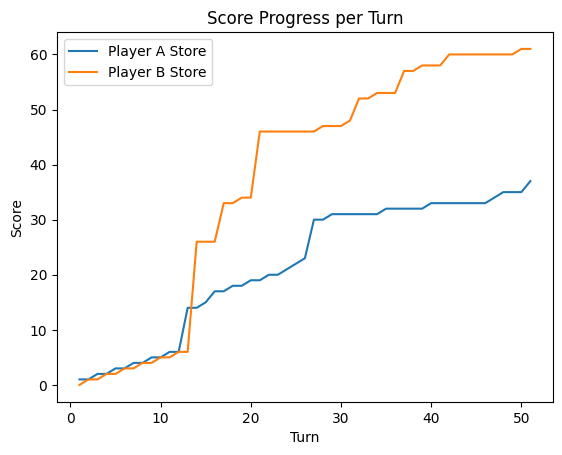

In [6]:
board, trace, first_A, first_B = play_game(greedy_strategy, lookahead_strategy)
plot_score_progress(trace)

In [7]:
def display_all_steps(trace_df):
    print(f"=== Showing {len(trace_df)} moves total ===")
    for index, row in trace_df.iterrows():
        print(f"\nMove {row['turn']} | Player: {row['player']} | Picked hole: {row['move']+1}")
        display_board(row['board'])
        print("-" * 40)

display_all_steps(trace)

=== Showing 51 moves total ===

Move 1 | Player: A | Picked hole: 4.0
    [ 7]  [ 7]  [ 7]  [ 7]  [ 8]  [ 8]  [ 8]
[ 0]                                        [ 1]
    [ 7]  [ 7]  [ 7]  [ 0]  [ 8]  [ 8]  [ 8]
----------------------------------------

Move 2 | Player: B | Picked hole: 7.0
    [ 0]  [ 7]  [ 7]  [ 7]  [ 8]  [ 8]  [ 8]
[ 1]                                        [ 1]
    [ 8]  [ 8]  [ 8]  [ 1]  [ 9]  [ 9]  [ 8]
----------------------------------------

Move 3 | Player: A | Picked hole: 6.0
    [ 1]  [ 8]  [ 8]  [ 8]  [ 9]  [ 9]  [ 9]
[ 1]                                        [ 2]
    [ 8]  [ 8]  [ 8]  [ 1]  [ 9]  [ 0]  [ 9]
----------------------------------------

Move 4 | Player: B | Picked hole: 1.0
    [ 2]  [ 9]  [ 9]  [ 9]  [10]  [10]  [ 0]
[ 2]                                        [ 2]
    [ 9]  [ 9]  [ 8]  [ 1]  [ 9]  [ 0]  [ 9]
----------------------------------------

Move 5 | Player: A | Picked hole: 3.0
    [ 2]  [ 9]  [ 9]  [ 9]  [11]  [11]  [ 1]
[ 2]     

## STEP 06 - Round-Robin Tournament

Every strategy plays every other strategy, both as A and as B, for `n_games` each.

In [8]:
def run_tournament(strategies, n_games=20, seed=42):
    random.seed(seed)
    rows = []
    for name_A, strat_A in strategies.items():
        for name_B, strat_B in strategies.items():
            wins_A = wins_B = draws = 0
            margins, lengths = [], []
            for _ in range(n_games):
                final_board, trace, _, _ = play_game(strat_A, strat_B)
                score_A, score_B = final_board[n_holes], final_board[-1]
                margins.append(score_A - score_B)
                lengths.append(int(trace["turn"].max()))
                if score_A > score_B:
                    wins_A += 1
                elif score_B > score_A:
                    wins_B += 1
                else:
                    draws += 1
            rows.append({
                "Player A": name_A, "Player B": name_B, "Games": n_games,
                "A Win %": 100 * wins_A / n_games,
                "B Win %": 100 * wins_B / n_games,
                "Draw %": 100 * draws / n_games,
                "Avg Margin (A-B)": sum(margins) / n_games,
                "Avg Game Length": sum(lengths) / n_games,
            })
    return pd.DataFrame(rows)

STRATEGIES = {
    "Random": random_strategy,
    "Greedy": greedy_strategy,
    "Lookahead": lookahead_strategy,
    "Minimax-3": minimax_shallow,
    "Minimax-6": minimax_deep,
}

tournament_results = run_tournament(STRATEGIES, n_games=20, seed=42)
tournament_results

,Player A,Player B,Games,A Win %,B Win %,Draw %,Avg Margin (A-B),Avg Game Length
0,Random,Random,20,40.0,55.0,5.0,-7.6,85.95
1,Random,Greedy,20,5.0,95.0,0.0,-33.3,57.10
2,Random,Lookahead,20,0.0,100.0,0.0,-50.7,69.20
3,Random,Minimax-3,20,0.0,100.0,0.0,-60.6,65.35
4,Random,Minimax-6,20,0.0,100.0,0.0,-62.5,51.85
5,Greedy,Random,20,100.0,0.0,0.0,41.4,58.65
6,Greedy,Greedy,20,50.0,45.0,5.0,0.3,44.90
7,Greedy,Lookahead,20,35.0,55.0,10.0,-3.1,62.20
8,Greedy,Minimax-3,20,20.0,80.0,0.0,-12.7,69.25
9,Greedy,Minimax-6,20,10.0,90.0,0.0,-30.8,64.80


## STEP 07 - Win-Rate Heatmap & Overall Ranking

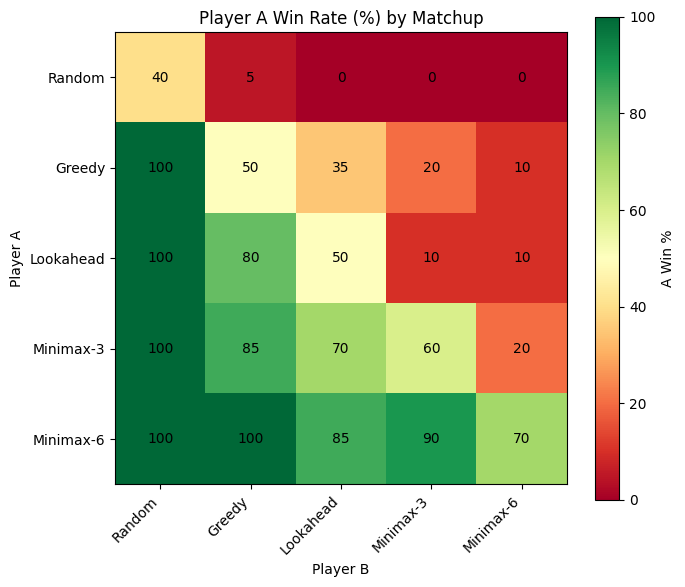

Player A
Minimax-6    83.0
Minimax-3    64.5
Lookahead    49.5
Greedy       39.0
Random       10.0
Name: Overall Win Rate %, dtype: float64

In [9]:
pivot = tournament_results.pivot(index="Player A", columns="Player B", values="A Win %")
order = list(STRATEGIES.keys())
pivot = pivot.reindex(index=order, columns=order)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("Player B")
ax.set_ylabel("Player A")
ax.set_title("Player A Win Rate (%) by Matchup")
for i in range(len(order)):
    for j in range(len(order)):
        ax.text(j, i, f"{pivot.values[i, j]:.0f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="A Win %")
plt.tight_layout()
plt.show()

as_A = tournament_results.groupby("Player A")["A Win %"].mean()
as_B = tournament_results.groupby("Player B")["B Win %"].mean()
overall_strength = ((as_A + as_B) / 2).sort_values(ascending=False)
overall_strength.name = "Overall Win Rate %"
display(overall_strength.round(1))

## STEP 08 - Opening-Move Study

Force Player A's first move to each possible hole, then let Minimax-6 (A) vs. Lookahead (B) play out normally, repeated `n_games` times per opening.

In [10]:
def play_game_forced_opening(opening_move, strategy_A, strategy_B):
    global n_holes
    board = init_board()
    turn = 'A'
    turn_count = 0
    opening_used = False

    while not game_over(board):
        turn_count += 1
        if turn == 'A':
            move = opening_move if not opening_used else strategy_A(board, 'A')
            opening_used = True
            board, extra = simulate_move(board, move, 'A')
            turn = 'A' if extra else 'B'
        else:
            move = strategy_B(board, 'B')
            board, extra = simulate_move(board, move, 'B')
            turn = 'B' if extra else 'A'

    board[n_holes] += sum(board[:n_holes])
    board[-1] += sum(board[n_holes+1:-1])
    return board

def run_opening_experiment(strategy_A, strategy_B, n_games=15, seed=7):
    random.seed(seed)
    rows = []
    for opening in range(n_holes):
        wins = draws = 0
        margins = []
        for _ in range(n_games):
            final_board = play_game_forced_opening(opening, strategy_A, strategy_B)
            score_A, score_B = final_board[n_holes], final_board[-1]
            margins.append(score_A - score_B)
            if score_A > score_B:
                wins += 1
            elif score_A == score_B:
                draws += 1
        rows.append({
            "Opening Hole": opening + 1,
            "A Win %": 100 * wins / n_games,
            "Draw %": 100 * draws / n_games,
            "Avg Margin (A-B)": sum(margins) / n_games,
        })
    return pd.DataFrame(rows)

opening_results = run_opening_experiment(minimax_deep, lookahead_strategy, n_games=15, seed=7)
opening_results

,Opening Hole,A Win %,Draw %,Avg Margin (A-B)
0,1,80.000000,0.000000,23.333333
1,2,93.333333,0.000000,30.400000
2,3,93.333333,0.000000,25.733333
3,4,100.000000,0.000000,42.000000
4,5,100.000000,0.000000,38.400000
5,6,100.000000,0.000000,28.133333
6,7,93.333333,6.666667,31.066667


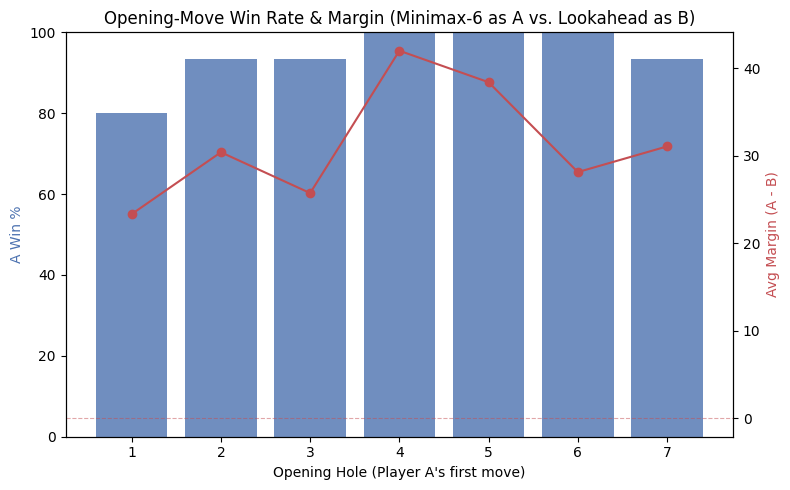

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(opening_results["Opening Hole"], opening_results["A Win %"], color="#4C72B0", alpha=0.8, label="A Win %")
ax1.set_xlabel("Opening Hole (Player A's first move)")
ax1.set_ylabel("A Win %", color="#4C72B0")
ax1.set_xticks(opening_results["Opening Hole"])
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.plot(opening_results["Opening Hole"], opening_results["Avg Margin (A-B)"], color="#C44E52", marker="o", label="Avg Margin")
ax2.set_ylabel("Avg Margin (A - B)", color="#C44E52")
ax2.axhline(0, color="#C44E52", lw=0.8, linestyle="--", alpha=0.5)

plt.title("Opening-Move Win Rate & Margin (Minimax-6 as A vs. Lookahead as B)")
fig.tight_layout()
plt.show()

## STEP 09 - Score Progression Across Many Games

Replay a matchup many times and look at the score margin (mean +/- std) and the probability Player A is actually leading, turn by turn.

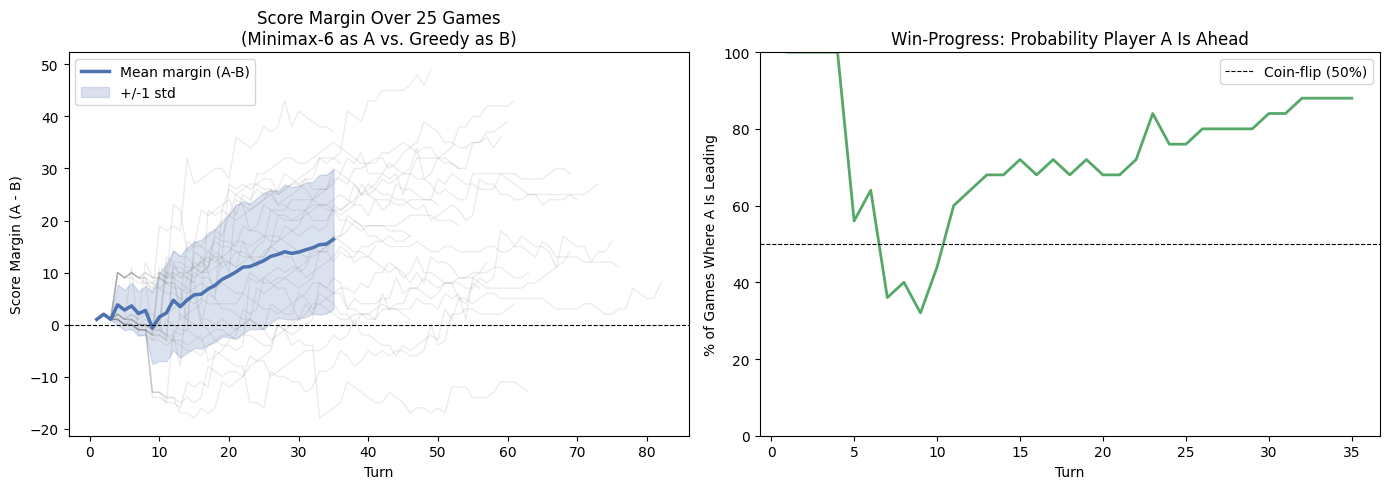

Game length across 25 games -- min: 35, mean: 58.0, max: 82


In [12]:
def collect_progress_data(strategy_A, strategy_B, n_games=25, seed=99):
    random.seed(seed)
    traces, lengths = [], []
    for _ in range(n_games):
        _, trace, _, _ = play_game(strategy_A, strategy_B)
        trace = trace[trace["player"] != "FINAL"]
        traces.append(trace)
        lengths.append(len(trace))
    return traces, lengths

traces, lengths = collect_progress_data(minimax_deep, greedy_strategy, n_games=25, seed=99)
min_len = min(lengths)
turns = np.arange(1, min_len + 1)

margin_matrix = np.array([
    (t["store_A"].values[:min_len] - t["store_B"].values[:min_len]) for t in traces
])
mean_margin = margin_matrix.mean(axis=0)
std_margin = margin_matrix.std(axis=0)
lead_prob = (margin_matrix > 0).mean(axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for t in traces:
    ax.plot(t["turn"], t["store_A"] - t["store_B"], color="gray", alpha=0.15, lw=1)
ax.plot(turns, mean_margin, color="#4C72B0", lw=2.5, label="Mean margin (A-B)")
ax.fill_between(turns, mean_margin - std_margin, mean_margin + std_margin, color="#4C72B0", alpha=0.2, label="+/-1 std")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Turn")
ax.set_ylabel("Score Margin (A - B)")
ax.set_title(f"Score Margin Over {len(traces)} Games\n(Minimax-6 as A vs. Greedy as B)")
ax.legend()

ax2 = axes[1]
ax2.plot(turns, lead_prob, color="#55A868", lw=2)
ax2.axhline(50, color="black", lw=0.8, linestyle="--", label="Coin-flip (50%)")
ax2.set_xlabel("Turn")
ax2.set_ylabel("% of Games Where A Is Leading")
ax2.set_title("Win-Progress: Probability Player A Is Ahead")
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Game length across {len(traces)} games -- min: {min(lengths)}, mean: {np.mean(lengths):.1f}, max: {max(lengths)}")

## Conclusion

Minimax-6 dominates every shallower strategy; Minimax-3 can still lose to Lookahead in some matchups, showing search depth isn't free. Openings are close to symmetric (win rate/margin roughly flat across holes). The win-progress chart separates lead *size* from lead *reliability* — a strategy can average a big margin while only actually leading in ~55% of games.

## STEP 10 - Play Against the Computer (optional, interactive)

Not run automatically (needs keyboard input) — uncomment `play_against_human(...)` at the bottom to try it.

In [13]:
def save_game_log(strategy_name, logs):
    import os
    import datetime
    result_dir = "../result"
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
        print(f"\n[System] Created directory {result_dir}.")

    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    file_name = f"{strategy_name} - {timestamp}.txt"
    full_path = os.path.join(result_dir, file_name)

    try:
        with open(full_path, "w", encoding="utf-8") as f:
            f.write("\n".join(logs))
        print(f"[System] Game log saved to: {full_path}")
    except Exception as e:
        print(f"[Error] Failed to save log: {e}")

def play_against_human(computer_strategy):
    global n_holes
    board = init_board()
    _total_len = len(board)
    game_log = []

    print(f"=== Congklak Game: {n_holes} Holes ===")
    strategy_label = computer_strategy.__name__

    role = input("Choose: 1 for Player A (goes first), 2 for Player B (goes second): ")
    human = 'A' if role == '1' else 'B'
    comp = 'B' if human == 'A' else 'A'

    def log_and_print(msg):
        print(msg)
        game_log.append(msg)

    def get_visual_board(b):
        top = "    " + "  ".join(f"[{b[i]:2}]" for i in range(_total_len - 2, n_holes, -1))
        middle = f"[{b[_total_len-1]:2}]" + " " * (n_holes * 6) + f" [{b[n_holes]:2}]"
        bottom = "    " + "  ".join(f"[{b[i]:2}]" for i in range(0, n_holes))
        return f"{top}\n{middle}\n{bottom}\n"

    def show(b):
        if human == 'A':
            log_and_print(get_visual_board(b))
        else:
            flipped = [0] * _total_len
            for i in range(n_holes):
                flipped[i] = b[n_holes + 1 + i]
                flipped[n_holes + 1 + i] = b[i]
            flipped[n_holes], flipped[-1] = b[-1], b[n_holes]
            log_and_print("\n(View: Your side [Player B] at the bottom)")
            log_and_print(get_visual_board(flipped))

    turn = 'A'
    show(board)
    while not game_over(board):
        log_and_print(f"\n>>> Player {turn}'s turn <<<")
        if turn == human:
            offset = 0 if human == 'A' else n_holes + 1
            valid_choices = [i + 1 for i in range(n_holes) if board[offset + i] > 0]
            choice = -1
            while choice not in valid_choices:
                try:
                    choice = int(input(f"Choose your hole {valid_choices}: "))
                except: pass

            move_idx = choice - 1
            board, extra = simulate_move(board, move_idx, human)
            log_and_print(f"You chose hole: {choice}")
        else:
            log_and_print("Computer thinking...")
            move_idx = computer_strategy(board, comp)
            board, extra = simulate_move(board, move_idx, comp)
            view = move_idx + 1
            log_and_print(f"Computer chose hole: {view}")

        show(board)
        turn = turn if extra else ('B' if turn == 'A' else 'A')

    board[n_holes] += sum(board[:n_holes])
    board[-1] += sum(board[n_holes+1:-1])
    for i in range(_total_len):
        if i != n_holes and i != _total_len - 1: board[i] = 0

    log_and_print("\n=== FINAL RESULT ===")
    show(board)
    s_h = board[n_holes] if human == 'A' else board[-1]
    s_c = board[-1] if human == 'A' else board[n_holes]
    log_and_print(f"\nFINAL SCORE - You: {s_h} | Computer: {s_c}")

    save_game_log(strategy_label, game_log)

# play_against_human(make_minimax_strategy(depth=5))